# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Andres Velez Landaverea  
**Fecha:** 28 DE JUNIO DEL 2026  

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [2]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [5]:
# TODO: Cargar el dataset car.data
#
# Instrucciones:
# 1. Defina los nombres de columnas en una lista:
#    col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
# 2. Use pd.read_csv() para cargar 'car.data' con header=None y names=col_names
# 3. Imprima las dimensiones del dataset con df.shape
# 4. Muestre las primeras 5 filas con df.head()

col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header = None, names = col_names)
print("Dimensiones del dataset: ", df.shape)
df.head()

Dimensiones del dataset:  (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** B

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [7]:
# TODO: Explorar información del dataset
#
# Instrucciones:
# 1. Use df.info() para ver tipos de datos y valores no nulos
# 2. Use df.describe() para estadísticas descriptivas
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [8]:
# TODO: Verificar valores únicos por columna
#
# Instrucciones:
# 1. Use un loop for para recorrer df.columns
# 2. Para cada columna, imprima df[col].unique()
for col in df.columns:
  print(f"{col}: {df[col].unique()}")


buying: ['vhigh' 'high' 'med' 'low']
maint: ['vhigh' 'high' 'med' 'low']
doors: ['2' '3' '4' '5more']
persons: ['2' '4' 'more']
lug_boot: ['small' 'med' 'big']
safety: ['low' 'med' 'high']
class: ['unacc' 'acc' 'vgood' 'good']


In [9]:
# TODO: Verificar valores nulos
#
# Instrucciones:
# 1. Use df.isnull().sum() para contar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


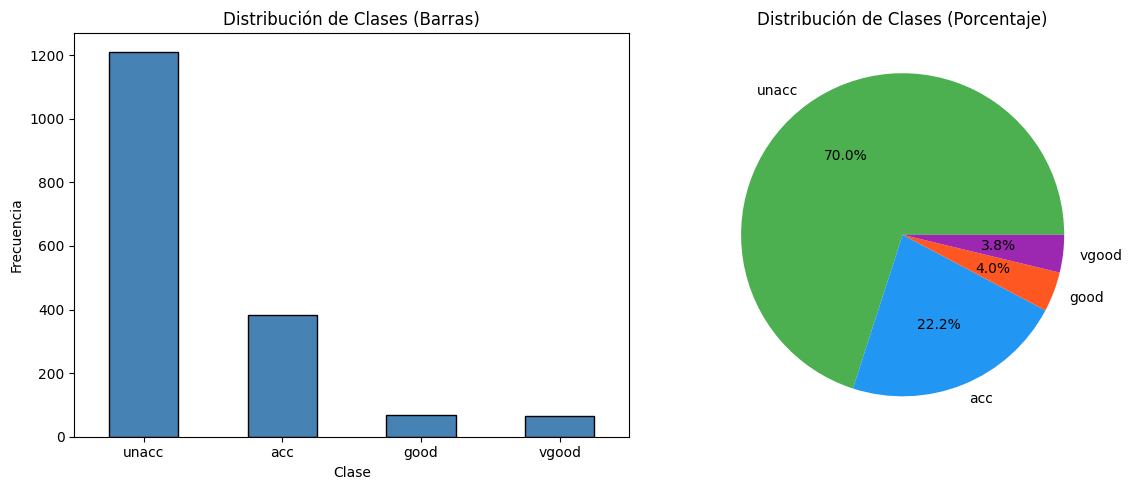


Conteo de clases:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [10]:
# TODO: Visualizar la distribución de la variable objetivo
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use df['class'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas apropiadas
# 5. Imprima el conteo de clases con df['class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['class'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Clases (Barras)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                                 colors=['#4CAF50','#2196F3','#FF5722','#9C27B0'])
axes[1].set_title('Distribución de Clases (Porcentaje)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nConteo de clases:")
print(df['class'].value_counts())


### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

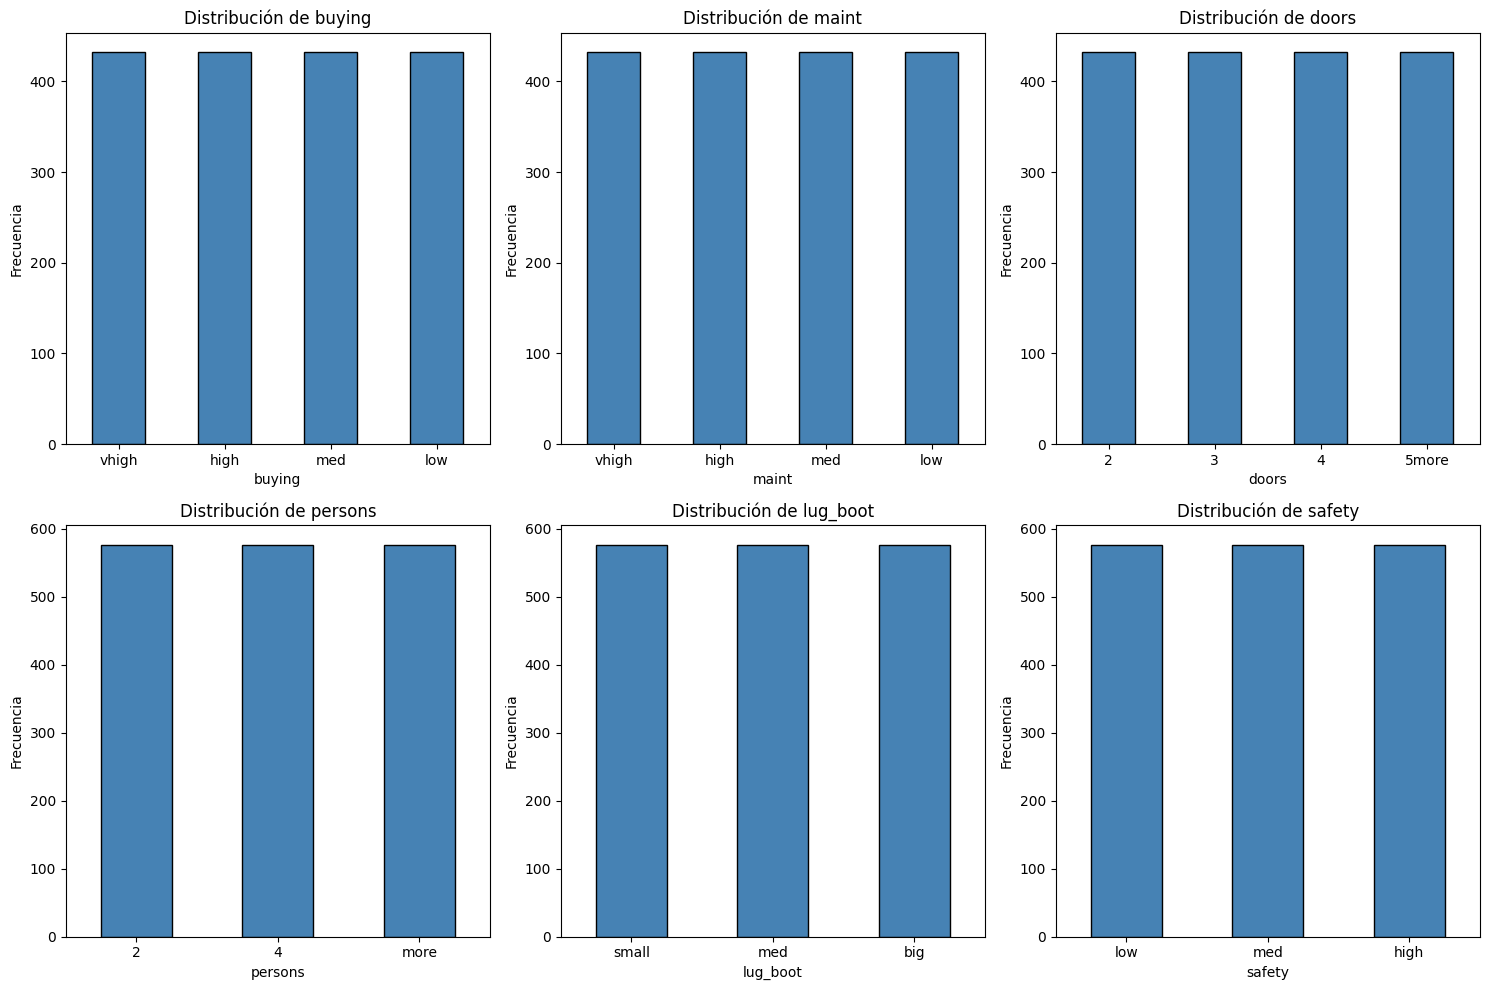

In [11]:
# TODO: Visualizar distribución de características
#
# Instrucciones:
# 1. Cree una figura con subplots 2x3 usando plt.subplots(2, 3, figsize=(15, 10))
# 2. Defina features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
# 3. Use un loop para graficar df[feature].value_counts().plot(kind='bar') en cada subplot
# 4. Agregue títulos a cada subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    df[feature].value_counts().plot(kind='bar', ax=axes[row][col],
                                     color='steelblue', edgecolor='black')
    axes[row][col].set_title(f'Distribución de {feature}')
    axes[row][col].set_xlabel(feature)
    axes[row][col].set_ylabel('Frecuencia')
    axes[row][col].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [12]:
# TODO: Aplicar Label Encoding a todas las columnas
#
# Instrucciones:
# 1. Cree una copia del DataFrame: df_encoded = df.copy()
# 2. Cree un diccionario vacío: label_encoders = {}
# 3. Para cada columna en df_encoded.columns:
#    a. Cree un LabelEncoder: le = LabelEncoder()
#    b. Transforme la columna: df_encoded[col] = le.fit_transform(df_encoded[col])
#    c. Guarde el encoder: label_encoders[col] = le
# 4. Muestre las primeras filas del DataFrame codificado
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Primeras filas del DataFrame codificado:")
df_encoded.head()


Primeras filas del DataFrame codificado:


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [13]:
# TODO: Mostrar el mapeo de etiquetas
#
# Instrucciones:
# 1. Para cada columna y encoder en label_encoders.items():
#    - Imprima el mapeo usando dict(zip(le.classes_, range(len(le.classes_))))
print("Mapeo de etiquetas por columna:")
for col, le in label_encoders.items():
    print(f"  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")


Mapeo de etiquetas por columna:
  buying: {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
  maint: {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
  doors: {'2': 0, '3': 1, '4': 2, '5more': 3}
  persons: {'2': 0, '4': 1, 'more': 2}
  lug_boot: {'big': 0, 'med': 1, 'small': 2}
  safety: {'high': 0, 'low': 1, 'med': 2}
  class: {'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B

## Parte 4: División de Datos

In [14]:
# TODO: Separar características (X) y variable objetivo (y)
#
# Instrucciones:
# 1. X = df_encoded.drop('class', axis=1) para obtener solo las características
# 2. y = df_encoded['class'] para obtener la variable objetivo
# 3. Imprima las formas de X y y
# 4. Imprima los nombres de las características con list(X.columns)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Características:", list(X.columns))


Forma de X: (1728, 6)
Forma de y: (1728,)
Características: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [15]:
# TODO: Dividir en conjuntos de entrenamiento y prueba
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.33, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba:        {X_test.shape[0]} muestras")


Tamaño entrenamiento: 1157 muestras
Tamaño prueba:        571 muestras


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [16]:
# TODO: Crear y entrenar el modelo con criterio Gini
#
# Instrucciones:
# 1. Cree el clasificador: clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
# 2. Entrene con clf_gini.fit(X_train, y_train)
# 3. Imprima la profundidad del árbol con clf_gini.get_depth()
# 4. Imprima el número de hojas con clf_gini.get_n_leaves()
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)

print("Profundidad del árbol:", clf_gini.get_depth())
print("Número de hojas:", clf_gini.get_n_leaves())


Profundidad del árbol: 3
Número de hojas: 5


In [17]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con y_pred_gini = clf_gini.predict(X_test)
# 2. Calcule la precisión en test con accuracy_score(y_test, y_pred_gini)
# 3. Prediga en train y calcule la precisión en entrenamiento
# 4. Imprima ambas precisiones
y_pred_gini = clf_gini.predict(X_test)

acc_gini_test  = accuracy_score(y_test, y_pred_gini)
acc_gini_train = accuracy_score(y_train, clf_gini.predict(X_train))

print(f"Precisión en entrenamiento: {acc_gini_train:.4f} ({acc_gini_train*100:.2f}%)")
print(f"Precisión en prueba:        {acc_gini_test:.4f} ({acc_gini_test*100:.2f}%)")


Precisión en entrenamiento: 0.7744 (77.44%)
Precisión en prueba:        0.7653 (76.53%)


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [18]:
# TODO: Crear y entrenar el modelo con criterio Entropy
#
# Instrucciones:
# 1. Cree el clasificador: clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# 2. Entrene con clf_entropy.fit(X_train, y_train)
# 3. Imprima la profundidad y número de hojas
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_entropy.fit(X_train, y_train)

print("Profundidad del árbol:", clf_entropy.get_depth())
print("Número de hojas:", clf_entropy.get_n_leaves())


Profundidad del árbol: 3
Número de hojas: 5


In [19]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con clf_entropy.predict(X_test)
# 2. Calcule y muestre la precisión en test y train
y_pred_entropy = clf_entropy.predict(X_test)

acc_ent_test  = accuracy_score(y_test, y_pred_entropy)
acc_ent_train = accuracy_score(y_train, clf_entropy.predict(X_train))

print(f"Precisión en entrenamiento: {acc_ent_train:.4f} ({acc_ent_train*100:.2f}%)")
print(f"Precisión en prueba:        {acc_ent_test:.4f} ({acc_ent_test*100:.2f}%)")


Precisión en entrenamiento: 0.7744 (77.44%)
Precisión en prueba:        0.7653 (76.53%)


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [20]:
# TODO: Crear tabla comparativa
#
# Instrucciones:
# 1. Cree un DataFrame con las siguientes columnas:
#    - 'Criterio': ['Gini Index', 'Entropy']
#    - 'Precisión Train': precisiones de entrenamiento
#    - 'Precisión Test': precisiones de prueba
#    - 'Profundidad': profundidad de cada árbol
#    - 'Hojas': número de hojas de cada árbol
# 2. Imprima la tabla
resultados = pd.DataFrame({
    'Criterio':         ['Gini Index', 'Entropy'],
    'Precisión Train':  [round(acc_gini_train, 4), round(acc_ent_train, 4)],
    'Precisión Test':   [round(acc_gini_test,  4), round(acc_ent_test,  4)],
    'Profundidad':      [clf_gini.get_depth(),    clf_entropy.get_depth()],
    'Hojas':            [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]
})

print("Tabla Comparativa de Modelos:")
print(resultados.to_string(index=False))


Tabla Comparativa de Modelos:
  Criterio  Precisión Train  Precisión Test  Profundidad  Hojas
Gini Index           0.7744          0.7653            3      5
   Entropy           0.7744          0.7653            3      5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B

## Parte 8: Matriz de Confusión y Métricas

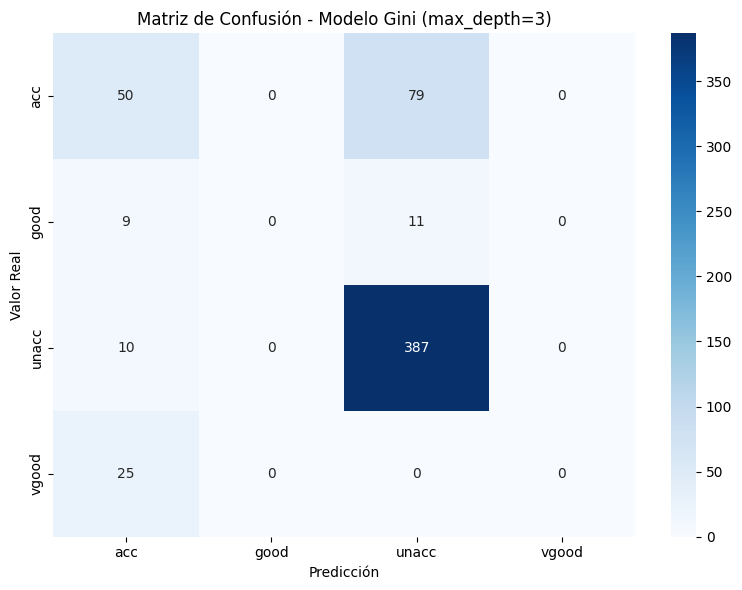

In [21]:
# TODO: Calcular y visualizar la matriz de confusión para el modelo Gini
#
# Instrucciones:
# 1. Calcule la matriz con confusion_matrix(y_test, y_pred_gini)
# 2. Obtenga los nombres de clase con label_encoders['class'].classes_
# 3. Use sns.heatmap() para visualizar con annot=True, fmt='d', cmap='Blues'
# 4. Configure xticklabels y yticklabels con los nombres de clase
# 5. Agregue título y etiquetas de ejes
class_names = label_encoders['class'].classes_
cm = confusion_matrix(y_test, y_pred_gini)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo Gini (max_depth=3)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()


In [22]:
# TODO: Imprimir el reporte de clasificación
#
# Instrucciones:
# 1. Use classification_report(y_test, y_pred_gini, target_names=class_names)
# 2. Imprima el reporte
print("Reporte de Clasificación - Modelo Gini (max_depth=3):")
print(classification_report(y_test, y_pred_gini, target_names=class_names))

Reporte de Clasificación - Modelo Gini (max_depth=3):
              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

## Parte 9: Visualización del Árbol de Decisión

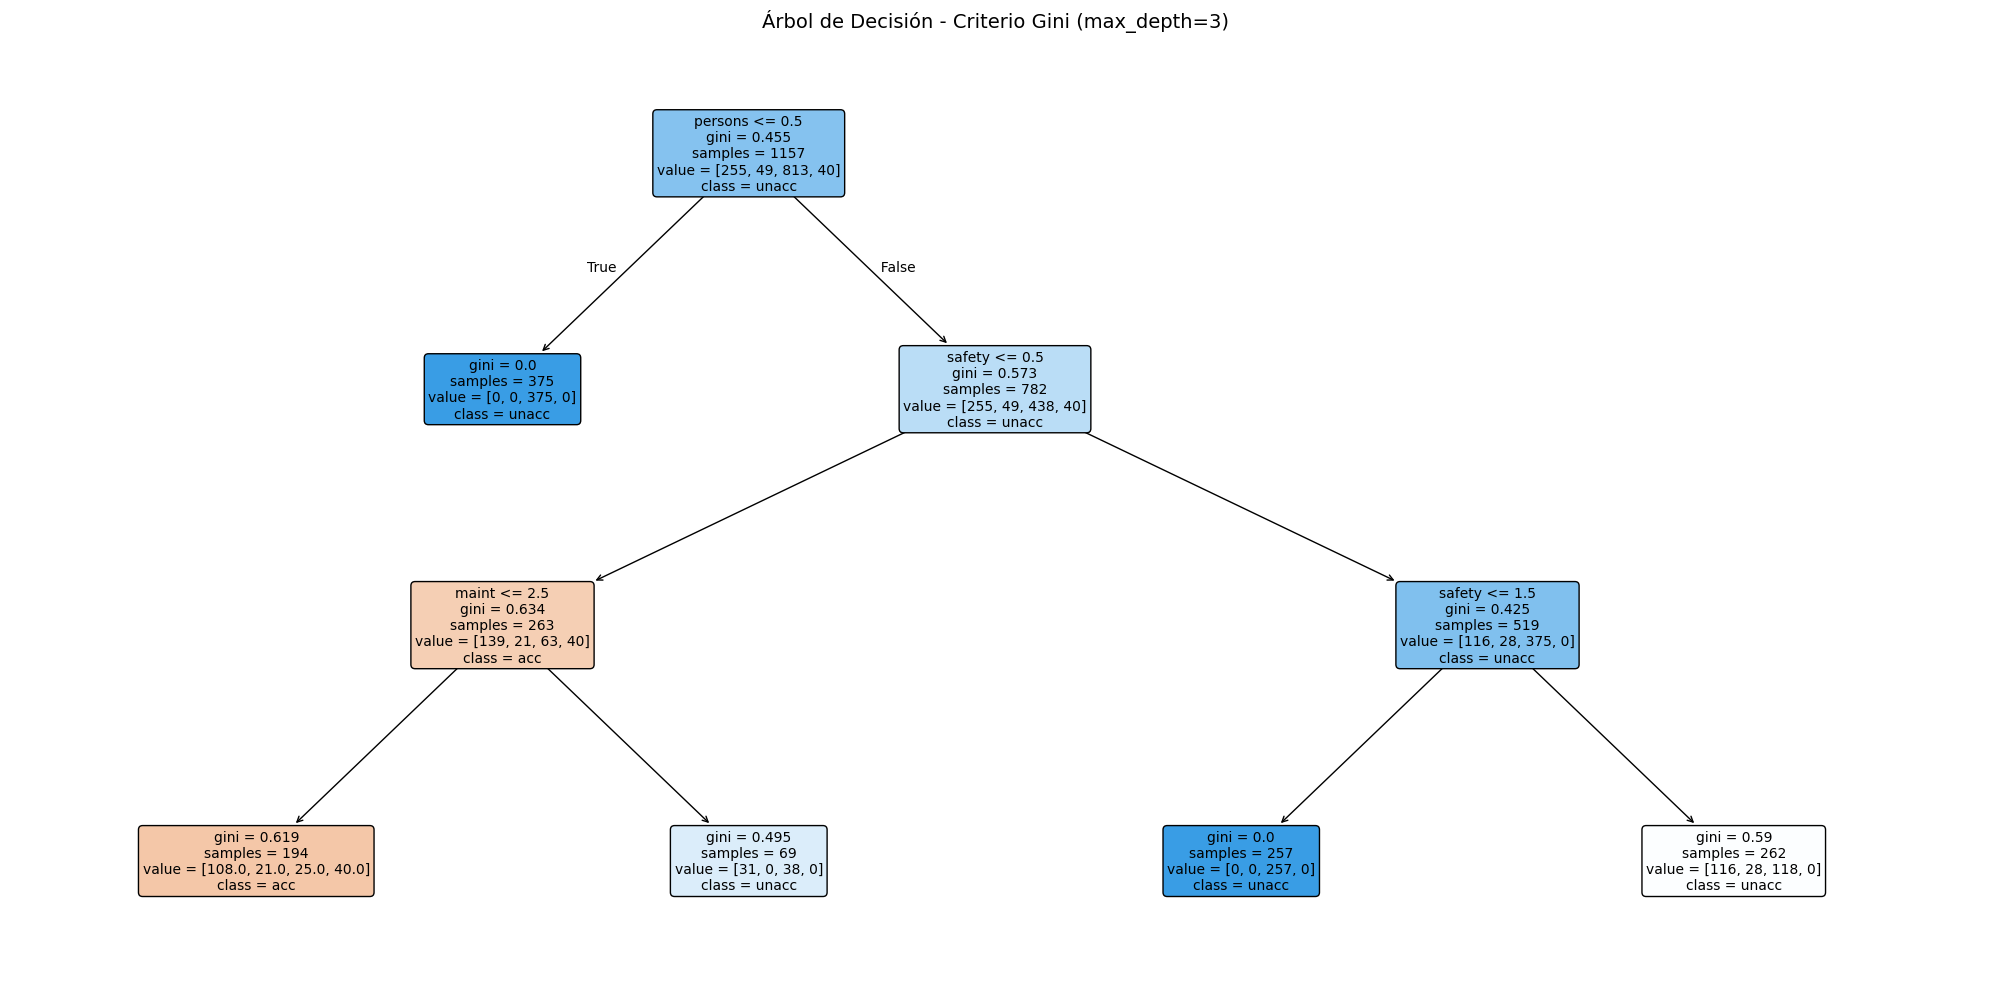

In [23]:
# TODO: Visualizar el árbol de decisión con Gini
#
# Instrucciones:
# 1. Cree una figura grande: plt.figure(figsize=(20, 10))
# 2. Use plot_tree() con los siguientes parámetros:
#    - clf_gini (el modelo)
#    - feature_names=list(X.columns)
#    - class_names=list(class_names)
#    - filled=True
#    - rounded=True
#    - fontsize=10
# 3. Agregue título
plt.figure(figsize=(20, 10))
plot_tree(clf_gini,
          feature_names=list(X.columns),
          class_names=list(class_names),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión - Criterio Gini (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()


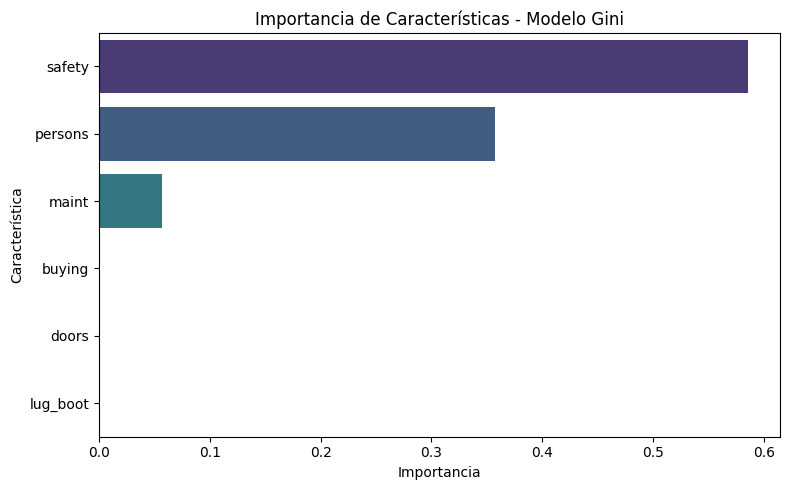


Tabla de importancias:
 Feature  Importance
  safety    0.585506
 persons    0.357400
   maint    0.057095
  buying    0.000000
   doors    0.000000
lug_boot    0.000000


In [24]:
# TODO: Mostrar la importancia de las características
#
# Instrucciones:
# 1. Cree un DataFrame con columnas 'Feature' y 'Importance'
#    - 'Feature': X.columns
#    - 'Importance': clf_gini.feature_importances_
# 2. Ordene por importancia descendente con sort_values()
# 3. Visualice con sns.barplot()
# 4. Imprima la tabla de importancias
feat_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': clf_gini.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Importancia de Características - Modelo Gini')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print("\nTabla de importancias:")
print(feat_importance.to_string(index=False))


### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [25]:
# TODO: Experimentar con diferentes valores de max_depth
#
# Instrucciones:
# 1. Defina depths = [1, 2, 3, 5, 7, 10, None] (None = sin límite)
# 2. Cree una lista vacía para resultados
# 3. Para cada depth:
#    a. Cree y entrene un DecisionTreeClassifier con ese max_depth
#    b. Calcule precisión en train y test
#    c. Guarde los resultados en un diccionario
# 4. Convierta a DataFrame e imprima
depths = [1, 2, 3, 5, 7, 10, None]
resultados_depth = []

for depth in depths:
    clf_d = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf_d.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf_d.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf_d.predict(X_test))
    resultados_depth.append({
        'max_depth':        str(depth),
        'Precisión Train':  round(train_acc, 4),
        'Precisión Test':   round(test_acc,  4),
        'Profundidad Real': clf_d.get_depth(),
        'Hojas':            clf_d.get_n_leaves()
    })

df_depth = pd.DataFrame(resultados_depth)
print("Efecto de max_depth en el rendimiento:")
print(df_depth.to_string(index=False))


Efecto de max_depth en el rendimiento:
max_depth  Precisión Train  Precisión Test  Profundidad Real  Hojas
        1           0.7027          0.6953                 1      2
        2           0.7684          0.7706                 2      3
        3           0.7744          0.7653                 3      5
        5           0.8557          0.8651                 5     13
        7           0.9300          0.9352                 7     28
       10           0.9931          0.9615                10     62
     None           1.0000          0.9667                14     73


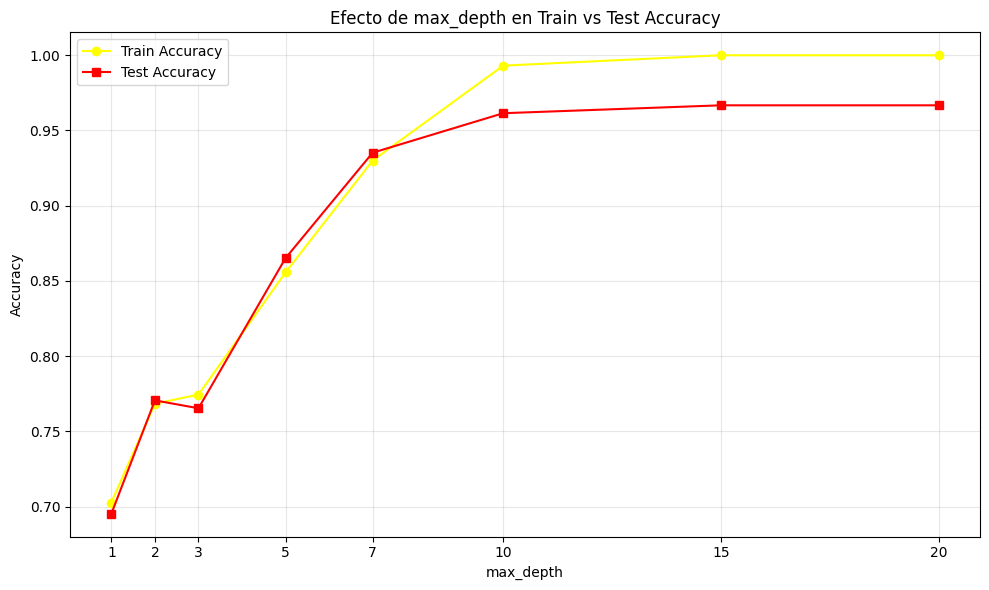

In [27]:
# TODO: Visualizar el efecto de max_depth
#
# Instrucciones:
# 1. Defina depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
# 2. Cree listas para train_scores y test_scores
# 3. Para cada depth, entrene un modelo y guarde las precisiones
# 4. Grafique ambas curvas (train y test) vs max_depth
# 5. Agregue leyenda, título y etiquetas
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
train_scores = []
test_scores  = []

for d in depths_plot:
    clf_d = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    clf_d.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf_d.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf_d.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_scores, 'o-', label='Train Accuracy', color='yellow')
plt.plot(depths_plot, test_scores,  's-', label='Test Accuracy',  color='red')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Efecto de max_depth en Train vs Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths_plot)
plt.tight_layout()
plt.show()


### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C

In [28]:
# TODO: Experimentar con min_samples_split
#
# Instrucciones:
# 1. Defina min_samples_list = [2, 5, 10, 20, 50]
# 2. Para cada valor, entrene un modelo SIN limitar max_depth
# 3. Guarde precisión train, test, profundidad y hojas
# 4. Imprima los resultados en una tabla
min_samples_list = [2, 5, 10, 20, 50]
resultados_mss = []

for mss in min_samples_list:
    clf_m = DecisionTreeClassifier(criterion='gini', min_samples_split=mss, random_state=42)
    clf_m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf_m.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf_m.predict(X_test))
    resultados_mss.append({
        'min_samples_split': mss,
        'Precisión Train':   round(train_acc, 4),
        'Precisión Test':    round(test_acc,  4),
        'Profundidad':       clf_m.get_depth(),
        'Hojas':             clf_m.get_n_leaves()
    })

df_mss = pd.DataFrame(resultados_mss)
print("Efecto de min_samples_split en el rendimiento:")
print(df_mss.to_string(index=False))


Efecto de min_samples_split en el rendimiento:
 min_samples_split  Precisión Train  Precisión Test  Profundidad  Hojas
                 2           1.0000          0.9667           14     73
                 5           0.9914          0.9562           12     62
                10           0.9767          0.9422           11     49
                20           0.9533          0.9317           10     38
                50           0.8911          0.8862            8     19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B

## Parte 11: Modelo Final Optimizado

In [29]:
# TODO: Entrenar modelo final con los mejores hiperparámetros
#
# Instrucciones:
# 1. Basado en sus experimentos, elija los mejores hiperparámetros
#    (sugerencia: criterion='gini', max_depth=7, min_samples_split=5)
# 2. Cree y entrene el modelo final
# 3. Calcule y muestre la precisión en test y train
# 4. Muestre profundidad y número de hojas
clf_final = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=5, random_state=42)
clf_final.fit(X_train, y_train)

y_pred_final = clf_final.predict(X_test)
acc_final_train = accuracy_score(y_train, clf_final.predict(X_train))
acc_final_test  = accuracy_score(y_test,  y_pred_final)

print(f"Precisión en entrenamiento: {acc_final_train:.4f} ({acc_final_train*100:.2f}%)")
print(f"Precisión en prueba:        {acc_final_test:.4f}  ({acc_final_test*100:.2f}%)")
print(f"Profundidad: {clf_final.get_depth()}, Hojas: {clf_final.get_n_leaves()}")


Precisión en entrenamiento: 0.9283 (92.83%)
Precisión en prueba:        0.9335  (93.35%)
Profundidad: 7, Hojas: 27


In [30]:
# TODO: Imprimir reporte de clasificación final
#
# Instrucciones:
# 1. Use classification_report() con las predicciones del modelo final
print("Reporte de Clasificación - Modelo Final Optimizado:")
print(classification_report(y_test, y_pred_final, target_names=class_names))


Reporte de Clasificación - Modelo Final Optimizado:
              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C